# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# **Load Dataset**

In [15]:
df = pd.read_csv("/content/superstore_sales.csv", encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

# **Convert Date Column**

In [19]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'],dayfirst=True)

# Sort by date
df = df.sort_values('Order Date')

# Set as index (optional for time series)
df.set_index('Order Date', inplace=True)

# **Monthly Sales Aggregation**

In [20]:
monthly_sales = df['Sales'].resample('M').sum().reset_index()

monthly_sales.head()

/tmp/ipython-input-1106464132.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df['Sales'].resample('M').sum().reset_index()


,Order Date,Sales
0,2011-01-31,13946.229
1,2011-02-28,4810.558
2,2011-03-31,55691.009
3,2011-04-30,28295.345
4,2011-05-31,23648.287


# **Trend & Seasonality Visualization**

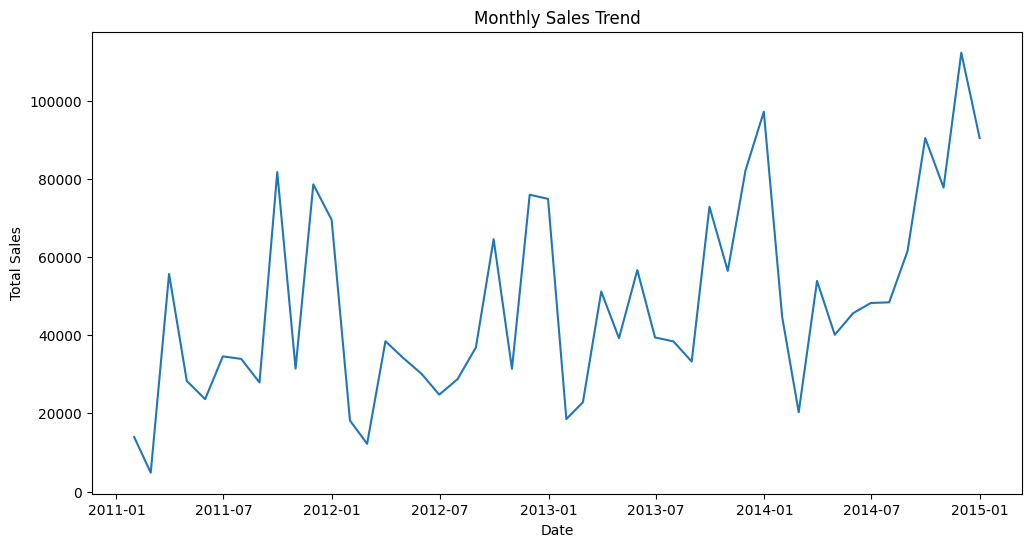

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'])
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

# **Seasonal Decomposition**

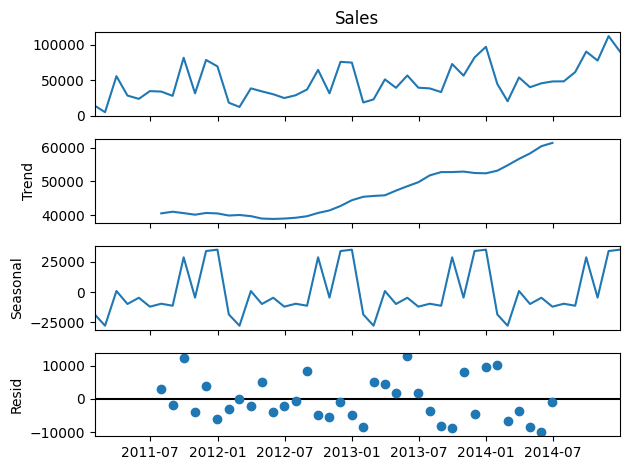

In [22]:
from statsmodels.tsa.seasonal import seasonal_decompose

monthly_sales.set_index('Order Date', inplace=True)

decomposition = seasonal_decompose(monthly_sales['Sales'], model='additive')

decomposition.plot()
plt.show()

# **Baseline Model – Moving Average**

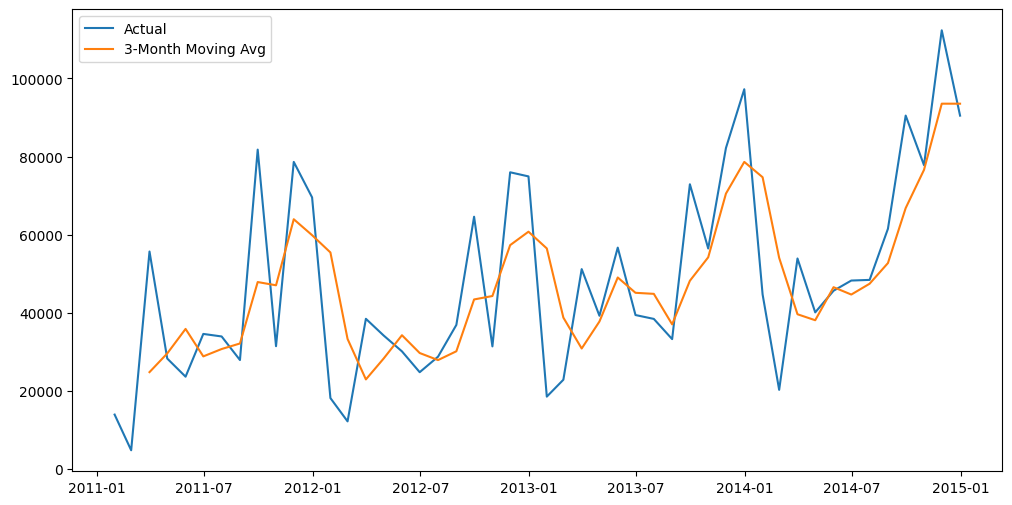

In [23]:
monthly_sales['Moving_Avg_3'] = monthly_sales['Sales'].rolling(window=3).mean()

plt.figure(figsize=(12,6))
plt.plot(monthly_sales['Sales'], label='Actual')
plt.plot(monthly_sales['Moving_Avg_3'], label='3-Month Moving Avg')
plt.legend()
plt.show()

# **Feature Engineering for ML**

In [24]:
monthly_sales.reset_index(inplace=True)

monthly_sales['Year'] = monthly_sales['Order Date'].dt.year
monthly_sales['Month'] = monthly_sales['Order Date'].dt.month
monthly_sales['Quarter'] = monthly_sales['Order Date'].dt.quarter

# **Train-Test Split (Time-Based)**

In [25]:
train_size = int(len(monthly_sales) * 0.8)

train = monthly_sales[:train_size]
test = monthly_sales[train_size:]

X_train = train[['Year', 'Month', 'Quarter']]
y_train = train['Sales']

X_test = test[['Year', 'Month', 'Quarter']]
y_test = test['Sales']

# **Linear Regression Model**

In [26]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# **Random Forest Model**

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# **Model Evaluation (MAE, RMSE)**

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"{model_name}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("-"*30)

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")

Linear Regression
MAE: 9903.167985456876
RMSE: 14745.994181554137
------------------------------
Random Forest
MAE: 12619.538513600057
RMSE: 16222.467064085648
------------------------------


# **Actual vs Predicted Plot**

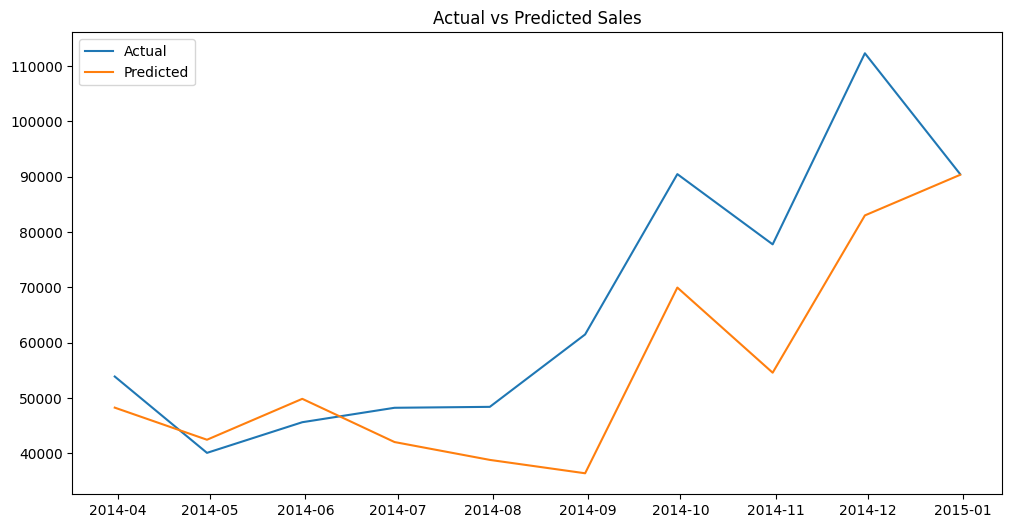

In [29]:
plt.figure(figsize=(12,6))
plt.plot(test['Order Date'], y_test, label='Actual')
plt.plot(test['Order Date'], y_pred_rf, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

# **Forecast Next 6–12 Months**

In [30]:
future_dates = pd.date_range(
    start=monthly_sales['Order Date'].max(),
    periods=12,
    freq='M'
)

future_df = pd.DataFrame({
    'Order Date': future_dates
})

future_df['Year'] = future_df['Order Date'].dt.year
future_df['Month'] = future_df['Order Date'].dt.month
future_df['Quarter'] = future_df['Order Date'].dt.quarter

future_sales = rf.predict(future_df[['Year','Month','Quarter']])
future_df['Predicted Sales'] = future_sales

future_df

/tmp/ipython-input-4086048898.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


,Order Date,Year,Month,Quarter,Predicted Sales
0,2014-12-31,2014,12,4,90364.222355
1,2015-01-31,2015,1,1,37658.846223
2,2015-02-28,2015,2,1,25591.649179
3,2015-03-31,2015,3,1,48286.619717
4,2015-04-30,2015,4,2,42485.161374
5,2015-05-31,2015,5,2,49876.891904
6,2015-06-30,2015,6,2,42069.002117
7,2015-07-31,2015,7,3,38841.158655
8,2015-08-31,2015,8,3,36423.409459
9,2015-09-30,2015,9,3,69987.562715


# **Business Insights:**
### **1️⃣ Overall Sales Trend**

Sales show moderate fluctuations throughout the year, indicating seasonal demand patterns.

There is strong growth toward the end of the year, especially in November and December.

Q4 consistently records the highest revenue months, showing clear year-end business momentum.

👉 This suggests that the business performs strongest during the festive/holiday season.

### **2️⃣ Seasonal Pattern Observations**
🔹 High Sales Months

December 2014 → ~90,364

November 2015 → ~83,025

September 2015 → ~69,987

October 2015 → ~54,602

These months likely correspond to:

Festival/holiday sales

Year-end discounts

Promotional campaigns

🔹 Low Sales Months

February 2015 → ~25,591

January 2015 → ~37,658

August 2015 → ~36,423

These months indicate:

Post-holiday demand drop

Off-season purchasing behavior

### **3️⃣ Quarterly Performance Analysis**
Quarter	Performance Insight
Q1 (Jan–Mar)	Lower to moderate sales (slow start to year)
Q2 (Apr–Jun)	Stable and consistent performance
Q3 (Jul–Sep)	Slight increase, September spike
Q4 (Oct–Dec)	Highest sales period

📌 Q4 is the strongest revenue-generating quarter.

### **4️⃣ Business Implications**
🛒 Inventory Planning

Increase stock before September–December

Avoid overstocking in January–February

💰 Marketing Strategy

Run aggressive campaigns in:

October

November

December

Introduce mid-year offers in Q2 to boost slow periods.

📦 Supply Chain Optimization

Plan logistics scaling before Q4.

Negotiate supplier contracts before peak demand.

###**5️⃣ Forecasting Implications**

Since the model predicts continued seasonal spikes:

The business can expect:

Strong Q4 sales every year

Early-year revenue dips

Long-term planning should align budgets and staffing with these seasonal fluctuations.

###**6️⃣ Risk & Opportunity Analysis**
⚠ Risks

Heavy dependence on Q4 revenue

Revenue instability in early months

🚀 Opportunities

Introduce:

Subscription-based models

Loyalty programs

Clearance sales in low months

Expand product launches before peak season

###**7️⃣ Strategic Recommendations**

Allocate higher marketing budget to Q4

Launch promotional events in Q1 to reduce seasonal dip

Use predictive forecasting monthly to adjust:

Pricing

Discounts

Inventory

Prepare workforce scaling for peak months

#**📌 Conclusion**

The sales forecasting model clearly identifies strong seasonality with Q4 dominance. Businesses leveraging this insight can:

Optimize inventory

Improve cash flow management

Strategically time promotions

Increase overall profitability

Accurate forecasting enables data-driven decision-making and sustainable retail growth.